In [ ]:
# !python3 train.py --all
# !python3 train.py --models gnn_timing
# !python3 train.py --models cnn_simplified_cross_attention_focal
!python3 train.py --models cnn_simplified_cross_attention_more_events

# MINOS Classifier Evaluation & Visualization Notebook

This notebook provides interactive evaluation, performance plots, event display snapshots, and leaderboard rankings for models trained using `train.py`.

In [2]:
# Setup & Module Imports
import sys
import os
import importlib
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sys.path.insert(0, str(Path.cwd()))

# Purge any stale in-memory cached imports for src
for mod in list(sys.modules.keys()):
    if mod == "src" or mod.startswith("src."):
        del sys.modules[mod]

import src
importlib.reload(src)

from src import (
    MINOSMultiViewGraphDataset,
    create_multiview_gnn_dataloaders,
    MODEL_CONFIGS,
    DATASET_CONFIG,
    get_config,
    validate_epoch,
    display_leaderboard,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using PyTorch Device: {device}")


Using PyTorch Device: cuda


## 1. Model Leaderboard & Ranking

Displays all trained models logged in `model_leaderboard.csv`, ranked by ROC-AUC.

In [3]:
# Display leaderboard of all trained models ranked by ROC-AUC
leaderboard = display_leaderboard(
    csv_path=DATASET_CONFIG.get("leaderboard_csv", "model_leaderboard.csv"),
    rank_by="roc_auc",
    ascending=False,
)



=================== MODEL LEADERBOARD (Ranked by ROC_AUC) ===================


,timestamp,git_hash,model_type,model_name,num_params,roc_auc,f1,accuracy,val_loss,threshold,num_epochs,batch_size,lr,step_size,gamma,weight_decay,feature_mode,max_events,model_path
Rank,,,,,,,,,,,,,,,,,,,
1,2026-08-06 15:41:27,e1cf805,gnn_timing,TimingAwareGNN,53738,0.9396,0.9192,0.8777,0.2628,0.458,20,32,0.001,5,0.5,0.0001,timing,11694,saved_models/gnn_timing_20260806_154127_e1cf80...
2,2026-08-05 13:07:07,230aa54,cnn_deep_resnet_cross_attention,DualViewDeepResNetCrossAttentionSparseCNN,988626,0.9378,0.9171,0.8704,0.2585,0.409,15,32,0.001,4,0.5,0.0001,sum,12000,saved_models/cnn_deep_resnet_cross_attention_2...
3,2026-08-05 11:35:35,230aa54,cnn_resnet_cross_attention,DualViewResNetCrossAttentionSparseCNN,236210,0.9361,0.9130,0.8606,0.2610,0.419,15,32,0.001,4,0.5,0.0001,sum,12000,saved_models/cnn_resnet_cross_attention_202608...
4,2026-08-05 11:35:35,230aa54,cnn_resnet_cross_attention,DualViewResNetCrossAttentionSparseCNN,236210,0.9361,0.9130,0.8606,0.2610,0.419,15,32,0.001,4,0.5,0.0001,sum,12000,saved_models/cnn_resnet_cross_attention_202608...
5,2026-08-05 11:23:36,230aa54,cnn_deep_cross_attention,DualViewDeepCrossAttentionSparseCNN,124850,0.9360,0.9145,0.8678,0.2616,0.478,12,32,0.001,3,0.3,0.0001,sum,12000,saved_models/cnn_deep_cross_attention_20260805...
6,2026-08-05 11:23:36,230aa54,cnn_deep_cross_attention,DualViewDeepCrossAttentionSparseCNN,124850,0.9360,0.9145,0.8678,0.2616,0.478,12,32,0.001,3,0.3,0.0001,sum,12000,saved_models/cnn_deep_cross_attention_20260805...
7,2026-08-05 11:16:43,230aa54,cnn_cross_attention,DualViewCrossAttentionSparseCNN,50738,0.9356,0.9162,0.8687,0.2624,0.458,12,32,0.001,3,0.3,0.0001,sum,12000,saved_models/cnn_cross_attention_20260805_1116...
8,2026-08-05 11:16:43,230aa54,cnn_cross_attention,DualViewCrossAttentionSparseCNN,50738,0.9356,0.9162,0.8687,0.2624,0.458,12,32,0.001,3,0.3,0.0001,sum,12000,saved_models/cnn_cross_attention_20260805_1116...
9,2026-08-05 12:11:26,230aa54,cnn_multistage_cross_attention,DualViewMultiStageCrossAttentionSparseCNN,84274,0.9346,0.9145,0.8636,0.2638,0.434,12,32,0.001,3,0.3,0.0001,sum,12000,saved_models/cnn_multistage_cross_attention_20...


## 2. Load Trained Model Checkpoint for Analysis

Select a trained checkpoint path (or automatically pick the top-ranked model from the leaderboard) to load weights and evaluate.

In [ ]:
# Select checkpoint path to evaluate (default: top model from leaderboard or latest checkpoint)
checkpoint_path = None

if leaderboard is not None and not leaderboard.empty:
    top_row = leaderboard.iloc[0]
    checkpoint_path = top_row.get("model_path")
    print(f"Selected Top Leaderboard Checkpoint: {checkpoint_path}")
else:
    # Fallback to search saved_models directory
    save_dir = Path(DATASET_CONFIG.get("save_dir", "saved_models"))
    if save_dir.exists():
        pts = sorted(list(save_dir.glob("*.pt")), key=os.path.getmtime, reverse=True)
        if pts:
            checkpoint_path = str(pts[0])
            print(f"Selected Latest Checkpoint File: {checkpoint_path}")

if not checkpoint_path or not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"No valid model checkpoint found at '{checkpoint_path}'. Train a model first via 'python train.py'!")

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model_type = checkpoint.get("model_type", "cnn_resnet_cross_attention")
config = checkpoint.get("config", get_config(model_type))
saved_metrics = checkpoint.get("best_metrics", {})
history = checkpoint.get("history", None)

print(f"\nLoaded Checkpoint Metadata:")
print(f"  Model Type: {model_type}")
print(f"  Model Name: {config.get('model_name', model_type)}")
print(f"  Git Commit Hash: {checkpoint.get('git_hash', 'n/a')}")
print(f"  Saved Metrics: {saved_metrics}")


## 3. Prepare Dataset & Dataloaders

In [5]:
dataset = MINOSMultiViewGraphDataset(
    root_filepath=DATASET_CONFIG["root_filepath"],
    max_events=config.get("max_events", DATASET_CONFIG["max_events"]),
    view_ids=DATASET_CONFIG["view_ids"],
    plane_radius=DATASET_CONFIG["plane_radius"],
    strip_radius=DATASET_CONFIG["strip_radius"],
    feature_mode=config.get("feature_mode", DATASET_CONFIG["feature_mode"]),
    cache_path=DATASET_CONFIG["cache_path"],
    allow_root_fallback=DATASET_CONFIG.get("allow_root_fallback", True),
)

train_loader, val_loader, _, _ = create_multiview_gnn_dataloaders(
    dataset,
    batch_size=config.get("batch_size", 32),
    val_split=DATASET_CONFIG.get("val_split", 0.20),
    random_seed=DATASET_CONFIG.get("random_seed", 42),
)

sample_graph = dataset[0]
metadata = sample_graph.metadata()
graph_in_channels = sample_graph["view_a"].x.size(-1)

# Re-instantiate PyTorch model architecture and load saved state_dict
if config.get("is_gnn", False):
    model = config["model_factory"](metadata, graph_in_channels)
else:
    model = config["model"]

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()
print(f"Successfully instantiated '{config.get('model_name')}' with loaded model weights.")


AttributeError: 'GlobalStorage' object has no attribute 'metadata'

## 4. Training & Validation Performance Curves

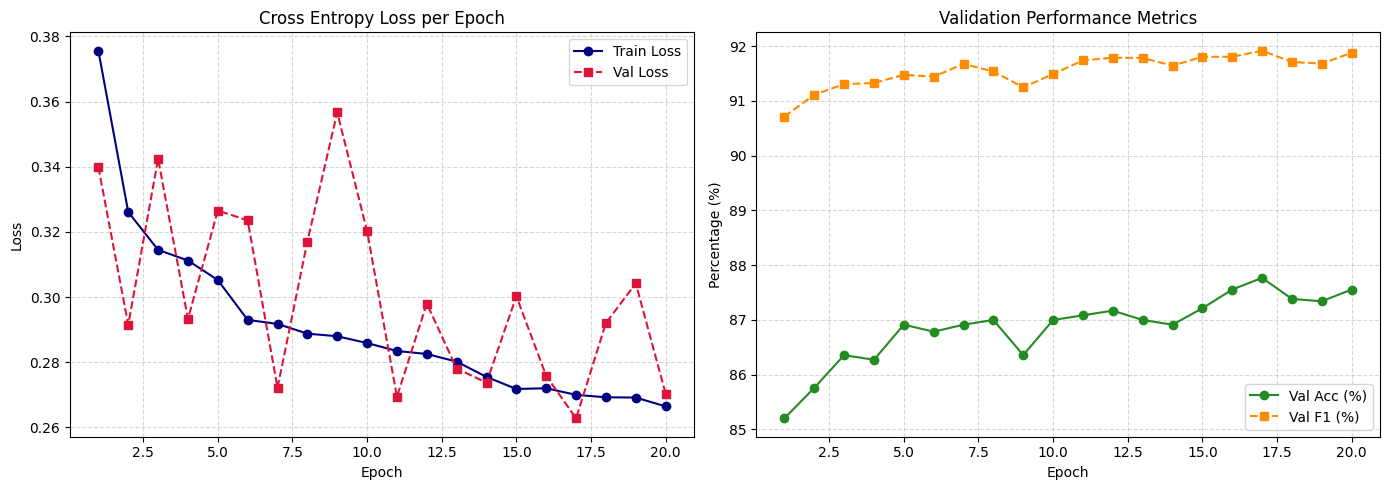

In [6]:
if history is not None and len(history.get("train_loss", [])) > 0:
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curves
    ax1.plot(epochs, history['train_loss'], 'o-', label='Train Loss', color='navy')
    ax1.plot(epochs, history['val_loss'], 's--', label='Val Loss', color='crimson')
    ax1.set_title('Cross Entropy Loss per Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()

    # Accuracy & F1 curves
    ax2.plot(epochs, [a * 100 for a in history['val_acc']], 'o-', label='Val Acc (%)', color='forestgreen')
    ax2.plot(epochs, [f * 100 for f in history['val_f1']], 's--', label='Val F1 (%)', color='darkorange')
    ax2.set_title('Validation Performance Metrics')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Percentage (%)')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No training history recorded in checkpoint. Skipping history curves.")


## 5. Validation Event Snapshots (Event Display)

In [ ]:
# Compute validation predictions for visualizations
val_loss, val_acc, val_metrics, val_probs, val_targets = validate_epoch(
    model, val_loader, device=device
)
opt_thresh = val_metrics.get("threshold", 0.5)

val_subset = val_loader.dataset
if hasattr(val_subset, 'indices'):
    sample_indices = list(val_subset.indices[:3])
    sample_graphs = [val_subset.dataset[i] for i in sample_indices]
else:
    sample_graphs = [val_subset[i] for i in range(min(3, len(val_subset)))]

view_names = ('view_a', 'view_b')
view_titles = {
    'view_a': f'View A (planeview={DATASET_CONFIG["view_ids"][0]})',
    'view_b': f'View B (planeview={DATASET_CONFIG["view_ids"][1]})',
}

def _event_score(graph):
    with torch.no_grad():
        graph = graph.to(device)
        logits = model(graph)
        probs = torch.softmax(logits, dim=1)
        return float(probs[0, 1].item())

n_events = len(sample_graphs)
fig, axes = plt.subplots(n_events, 2, figsize=(13, 4 * n_events), squeeze=False)

for row, graph in enumerate(sample_graphs):
    score = _event_score(graph)
    truth = int(graph.y.item())
    truth_label = 'CC' if truth == 1 else 'NC'
    pred_label = 'CC' if score >= opt_thresh else 'NC'

    for col, view_name in enumerate(view_names):
        ax = axes[row, col]
        coords = graph[view_name].pos.cpu().numpy()
        charges = graph[view_name].x[:, 0].cpu().numpy()
        scatter = ax.scatter(
            coords[:, 1],
            coords[:, 0],
            c=charges,
            s=18,
            cmap='viridis',
            alpha=0.9
        )
        ax.set_title(view_titles[view_name])
        ax.set_xlabel('Strip')
        ax.set_ylabel('Plane')
        ax.grid(True, linestyle='--', alpha=0.25)
        fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04, label='log1p(charge)')

        if col == 1:
            ax.text(
                0.02, 0.98,
                f'Truth: {truth_label}\nPred: {pred_label}\nScore(CC): {score:.3f}',
                transform=ax.transAxes,
                va='top',
                ha='left',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
            )

fig.suptitle('Validation Event Snapshots', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## 6. True Neutrino Energy & Model CC Score Distribution Histograms

In [ ]:
def _split_events(split_dataset):
    if hasattr(split_dataset, 'indices') and hasattr(split_dataset, 'dataset'):
        return [split_dataset.dataset[i] for i in split_dataset.indices]
    return [split_dataset[i] for i in range(len(split_dataset))]

def _event_label(event):
    if hasattr(event, 'y'):
        return int(event.y.item())
    return int(event['label'].item())

def _event_energy(event):
    if hasattr(event, 'true_energy'):
        return float(event.true_energy.item())
    return float(event['true_energy'].item())

def _collect_energies(split_dataset):
    energies_nc = []
    energies_cc = []
    for event in _split_events(split_dataset):
        energy = _event_energy(event)
        if _event_label(event) == 1:
            energies_cc.append(energy)
        else:
            energies_nc.append(energy)
    return np.array(energies_nc, dtype=float), np.array(energies_cc, dtype=float)

train_nc, train_cc = _collect_energies(train_loader.dataset)
val_nc, val_cc = _collect_energies(val_loader.dataset)
all_energy_arrays = [arr for arr in [train_nc, train_cc, val_nc, val_cc] if arr.size > 0]
all_energies = np.concatenate(all_energy_arrays) if all_energy_arrays else np.array([1.0])
max_energy = max(float(all_energies.max()), 1.0)
energy_bins = np.linspace(0.0, max_energy, 40)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, split_name, nc_vals, cc_vals in [
    (axes[0], 'Training', train_nc, train_cc),
    (axes[1], 'Validation', val_nc, val_cc),
]:
    ax.hist(nc_vals, bins=energy_bins, alpha=0.55, color='steelblue', label='NC', edgecolor='white')
    ax.hist(cc_vals, bins=energy_bins, alpha=0.55, color='darkorange', label='CC', edgecolor='white')
    ax.set_title(f'{split_name} True Neutrino Energy')
    ax.set_xlabel('True E_nu [GeV]')
    ax.set_ylabel('Events')
    ax.grid(True, linestyle='--', alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

score_bins = np.linspace(0.0, 1.0, 40)
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.hist(val_probs[val_targets == 0], bins=score_bins, alpha=0.55, color='steelblue', label='NC', edgecolor='white')
ax.hist(val_probs[val_targets == 1], bins=score_bins, alpha=0.55, color='darkorange', label='CC', edgecolor='white')
ax.axvline(opt_thresh, color="crimson", linestyle="--", linewidth=2, label=f"Optimal Threshold ({opt_thresh:.3f})")
ax.set_title(f"Validation Model Score by Truth (Optimal Threshold = {opt_thresh:.3f})")
ax.set_xlabel('Model Score for CC')
ax.set_ylabel('Events')
ax.grid(True, linestyle='--', alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()


## 7. True Neutrino Energy vs Model CC Score Scatter Plot

In [ ]:
val_events = _split_events(val_loader.dataset)
val_energies = np.array([_event_energy(ev) for ev in val_events])

fig, ax = plt.subplots(figsize=(9, 5.5))
mask_nc = (val_targets == 0)
mask_cc = (val_targets == 1)

ax.scatter(
    val_energies[mask_nc],
    val_probs[mask_nc],
    c='steelblue',
    marker='o',
    alpha=0.6,
    s=24,
    edgecolor='none',
    label=f'True NC (N={mask_nc.sum()})'
)
ax.scatter(
    val_energies[mask_cc],
    val_probs[mask_cc],
    c='darkorange',
    marker='^',
    alpha=0.6,
    s=24,
    edgecolor='none',
    label=f'True CC (N={mask_cc.sum()})'
)

ax.axhline(opt_thresh, color='crimson', linestyle='--', linewidth=2, label=f'Optimal Threshold ({opt_thresh:.3f})')
ax.set_title('Validation Events: True E_nu vs Model CC Score', fontsize=13)
ax.set_xlabel('True E_nu [GeV]', fontsize=11)
ax.set_ylabel('Model CC Score', fontsize=11)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()


## 8. Confusion Matrix & Accuracy Breakdown

In [10]:
val_preds = (val_probs >= opt_thresh).astype(int)
cm = confusion_matrix(val_targets, val_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NC (0)', 'CC (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title(f'Validation Confusion Matrix (Threshold = {opt_thresh:.3f})', fontsize=14)
plt.tight_layout()
plt.show()

nc_acc = cm[0, 0] / max(1, cm[0].sum()) * 100
cc_acc = cm[1, 1] / max(1, cm[1].sum()) * 100
print('Normalized Recall per Class:')
print(f'  NC Accuracy: {nc_acc:.2f}%')
print(f'  CC Accuracy: {cc_acc:.2f}%')


NameError: name 'val_probs' is not defined